# Train Actor-Critic

Actor-Critic updates a stochastic actor from one-step TD advantages estimated by a learned critic. This notebook trains it on `CartPole-v1` with a categorical policy, fixed-length rollouts, entropy regularization, and separate actor and critic optimizers.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from aprenderl import ActorCritic, ActorCriticConfig
from aprenderl.utils import evaluate_policy

ENV_ID = "CartPole-v1"

In [2]:
env = gym.make(ENV_ID)
config = ActorCriticConfig(
    learning_rate=1e-3,
    value_learning_rate=1e-3,
    gamma=0.99,
    n_steps=32,
    entropy_coefficient=1e-3,
)

agent = ActorCritic(env, config=config, device="cpu")
agent.learn(total_timesteps=20_000)
env.close()

ActorCritic:   0%|          | 0/20000 [00:00<?, ?step/s]

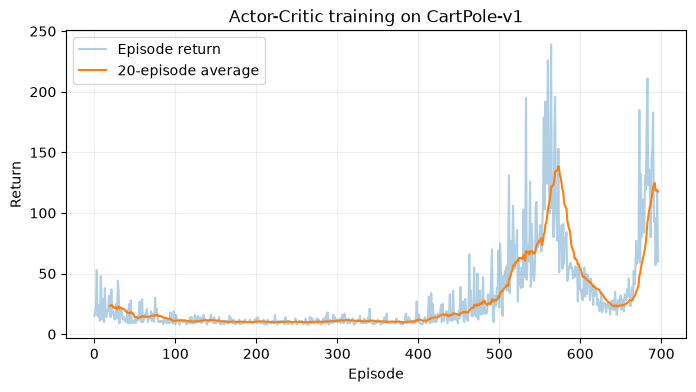

In [3]:
returns = np.asarray(agent.episode_returns)
window = min(20, len(returns))
moving_average = np.convolve(returns, np.ones(window) / window, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(returns, alpha=0.35, label="Episode return")
plt.plot(
    np.arange(window - 1, len(returns)),
    moving_average,
    label=f"{window}-episode average",
)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title(f"Actor-Critic training on {ENV_ID}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Watch the trained policy

This opens a window and runs five episodes using deterministic actions.

In [4]:
evaluation_env = gym.make(ENV_ID, render_mode="human")
try:
    result = evaluate_policy(agent, evaluation_env, episodes=5)
finally:
    evaluation_env.close()

print("Episode returns:", result.returns)
print(f"Mean return: {result.mean_return:.1f} +/- {result.return_std:.1f}")

Episode returns: (99.0, 61.0, 86.0, 68.0, 65.0)
Mean return: 75.8 +/- 14.4
